In [1]:
# Download iris.csv if not already present
import requests
import os

file_name = 'iris.csv'
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'

if not os.path.exists(file_name):
    print(f'Downloading {file_name}...')
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f'{file_name} downloaded successfully.')
else:
    print(f'{file_name} already exists.')


iris.csv downloaded successfully.


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('iris.csv')

# Display the first few rows and information about the dataset
print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

# Separate features (X) and target (y)
X = df.drop('species', axis=1) # Features
y = df['species'] # Target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


Dataset Head:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Training set size: 105 samples
Testing set size: 45 samples


In [3]:
# Initialize the Random Forest classifier with default n_estimators (10)
rf_classifier_default = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier_default.fit(X_train, y_train)

# Make predictions on the test set
y_pred_default = rf_classifier_default.predict(X_test)

# Calculate the accuracy score
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Random Forest Classifier with default n_estimators (10) Accuracy: {accuracy_default:.4f}")


Random Forest Classifier with default n_estimators (10) Accuracy: 1.0000



Best accuracy achieved: 1.0000
Number of trees for best accuracy: 1


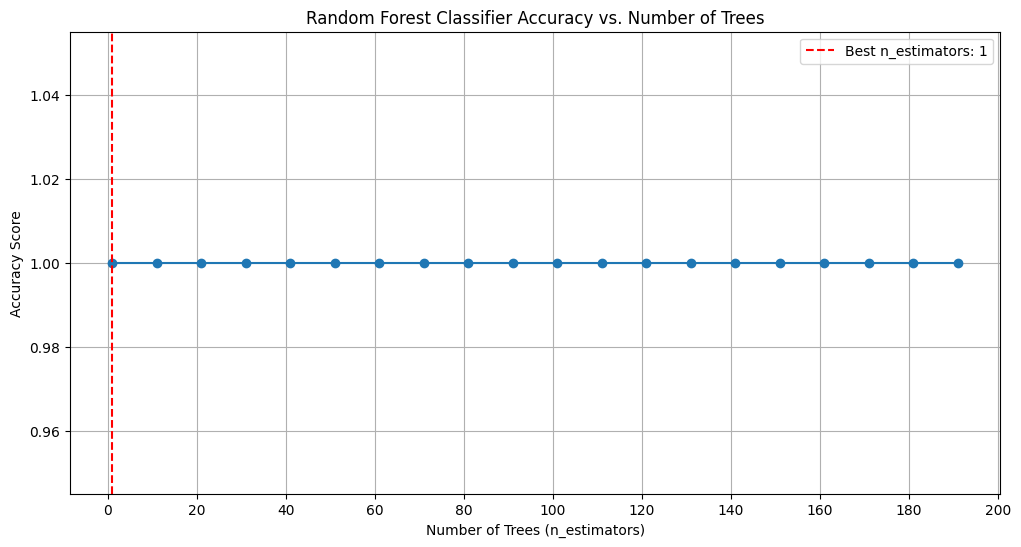

In [4]:
# Define a range of n_estimators to test
n_estimators_range = range(1, 201, 10) # From 1 to 200 with steps of 10

# Lists to store results
accuracy_scores = []

for n_estimators in n_estimators_range:
    # Initialize Random Forest classifier with the current n_estimators
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=42)

    # Train the model
    rf_classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_classifier.predict(X_test)

    # Calculate the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Find the best score and corresponding n_estimators
best_accuracy = np.max(accuracy_scores)
best_n_estimators = n_estimators_range[np.argmax(accuracy_scores)]

print(f"\nBest accuracy achieved: {best_accuracy:.4f}")
print(f"Number of trees for best accuracy: {best_n_estimators}")

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, accuracy_scores, marker='o', linestyle='-')
plt.title('Random Forest Classifier Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.xticks(np.arange(0, 201, 20))
plt.grid(True)
plt.axvline(x=best_n_estimators, color='r', linestyle='--', label=f'Best n_estimators: {best_n_estimators}')
plt.legend()
plt.show()
